# PyCaret (AutoML) vs. Regresión Logística: Telco Customer Churn
**Grupo:** Bryam Astudillo · Marcos Naranjo · Daniel Salcedo


**Dataset:** Telco Customer Churn (Kaggle, `blastchar/telco-customer-churn`)


**Objetivo:** predecir el abandono de clientes y comparar PyCaret con scikit-learn (F1, ROC-AUC y tiempo de entrenamiento).

| Sección | Responsable |
|---|---|
| 0-2. Datos, EDA y preprocesamiento | Marcos |
| 3. PyCaret | Bryam |
| 4. Regresión logística | Daniel |
| 5. Comparación final | Daniel y Bryam |

**Regla del grupo:** todos usan el mismo split (`test_size=0.2`, `random_state=42`, `stratify=y`). No lo modifiquen.

## 0. Configuración (Marcos)

In [ ]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42

In [ ]:
# Opción A: descarga directa desde Kaggle (dataset público, no necesita cuenta)
!pip install kagglehub -q
import kagglehub, os

ruta = kagglehub.dataset_download("blastchar/telco-customer-churn")
archivo = [f for f in os.listdir(ruta) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(ruta, archivo))
print("Archivo cargado:", archivo)
print("Dimensiones:", df.shape)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Archivo cargado: WA_Fn-UseC_-Telco-Customer-Churn.csv
Dimensiones: (7043, 21)


In [ ]:
# @title
# Opción B: subir el CSV a mano (ejecutar solo si la opción A falló)
if df is None:
  from google.colab import files
  subido = files.upload()
  df = pd.read_csv(list(subido.keys())[0])
print(df.shape)

(7043, 21)


## 1. Exploración inicial (Marcos)

In [ ]:
display(df.head())
print("\n--- Tipos de datos ---")
df.info()
print("\n--- Nulos por columna ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n--- Duplicados ---")
print(df.duplicated().sum())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  

In [ ]:
# TotalCharges viene como texto porque tiene espacios vacíos
vacios = df[df["TotalCharges"].str.strip() == ""]
print("Filas con TotalCharges vacío:", len(vacios))
display(vacios[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Filas con TotalCharges vacío: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## 2. Limpieza y preprocesamiento (Marcos)
Decisiones tomadas:
- `TotalCharges` se convierte a numérico. Los valores vacíos corresponden a clientes con `tenure = 0` (recién llegados, aún sin facturación), por lo que se imputan con 0.
- Se elimina `customerID`, ya que es un identificador sin valor predictivo.
- `Churn` se codifica como 1 = Yes y 0 = No.

In [ ]:
df_limpio = df.copy()

# 1) TotalCharges a numérico
df_limpio["TotalCharges"] = pd.to_numeric(df_limpio["TotalCharges"], errors="coerce")
print("Nulos en TotalCharges tras la conversión:", df_limpio["TotalCharges"].isnull().sum())

# 2) Comprobar que los nulos son de clientes con tenure = 0
print("Tenure de esos nulos:", df_limpio.loc[df_limpio["TotalCharges"].isnull(), "tenure"].unique())

# 3) Imputar con 0
df_limpio["TotalCharges"] = df_limpio["TotalCharges"].fillna(0)

# 4) Eliminar identificador
df_limpio = df_limpio.drop(columns=["customerID"])

# 5) Codificar la variable objetivo
df_limpio["Churn"] = df_limpio["Churn"].map({"Yes": 1, "No": 0}).astype(int)

print("\nDimensiones finales:", df_limpio.shape)
print("Nulos totales:", df_limpio.isnull().sum().sum())
display(df_limpio.head())

Nulos en TotalCharges tras la conversión: 11
Tenure de esos nulos: [0]

Dimensiones finales: (7043, 20)
Nulos totales: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2.1 Análisis exploratorio (Marcos)

Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


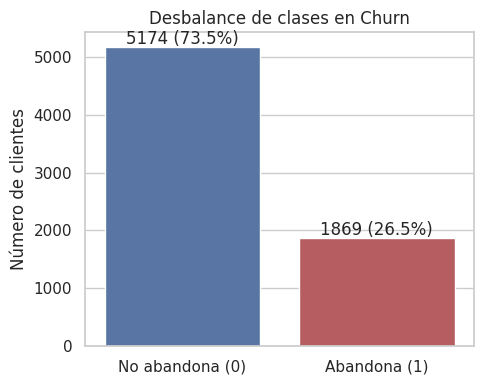

In [ ]:
conteo = df_limpio["Churn"].value_counts()
porcentaje = df_limpio["Churn"].value_counts(normalize=True) * 100
print(porcentaje.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df_limpio, x="Churn", palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xticklabels(["No abandona (0)", "Abandona (1)"])
ax.set_title("Desbalance de clases en Churn")
ax.set_xlabel("")
ax.set_ylabel("Número de clientes")
for i, v in enumerate(conteo.sort_index()):
    ax.text(i, v + 50, f"{v} ({porcentaje.sort_index().iloc[i]:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


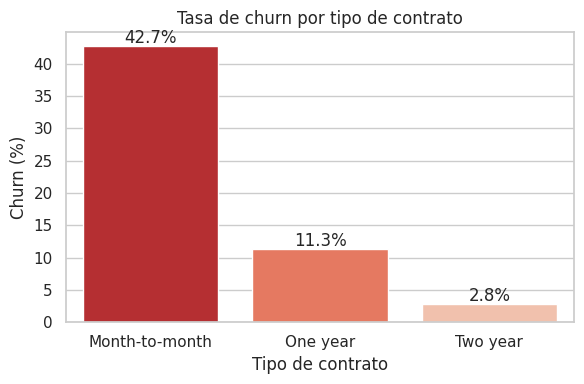

In [ ]:
tasa_contrato = df_limpio.groupby("Contract")["Churn"].mean().mul(100).sort_values(ascending=False)
print(tasa_contrato.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=tasa_contrato.index, y=tasa_contrato.values, palette="Reds_r", ax=ax)
ax.set_title("Tasa de churn por tipo de contrato")
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Churn (%)")
for i, v in enumerate(tasa_contrato.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

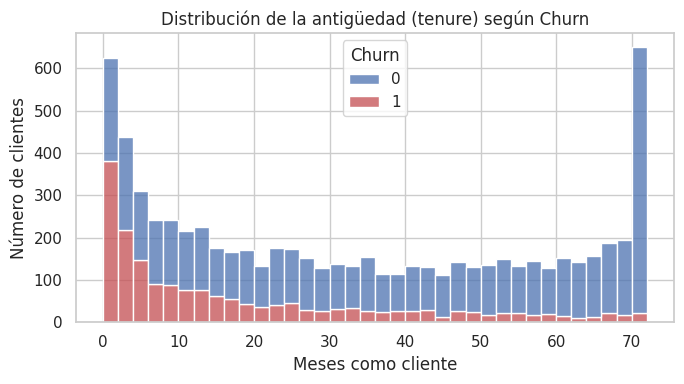

Tenure medio (meses) por grupo:
Churn
0    37.6
1    18.0
Name: tenure, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df_limpio, x="tenure", hue="Churn", bins=36, multiple="stack",
             palette={0: "#4C72B0", 1: "#C44E52"}, ax=ax)
ax.set_title("Distribución de la antigüedad (tenure) según Churn")
ax.set_xlabel("Meses como cliente")
ax.set_ylabel("Número de clientes")
plt.tight_layout()
plt.show()

print("Tenure medio (meses) por grupo:")
print(df_limpio.groupby("Churn")["tenure"].mean().round(1))

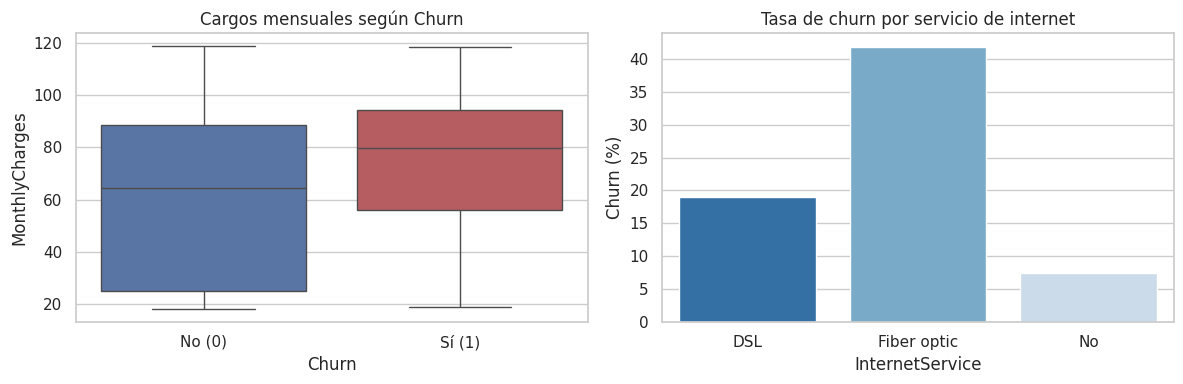

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df_limpio, x="Churn", y="MonthlyCharges", palette=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_title("Cargos mensuales según Churn")
axes[0].set_xticklabels(["No (0)", "Sí (1)"])

tasa_internet = df_limpio.groupby("InternetService")["Churn"].mean().mul(100)
sns.barplot(x=tasa_internet.index, y=tasa_internet.values, palette="Blues_r", ax=axes[1])
axes[1].set_title("Tasa de churn por servicio de internet")
axes[1].set_ylabel("Churn (%)")

plt.tight_layout()
plt.show()
print(tasa_internet.round(2))

In [ ]:
print(df_limpio.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"]).round(2))

        mean  median
Churn               
0      61.27   64.43
1      74.44   79.65


### Conclusiones del EDA (Marcos)

**Calidad de los datos:** el dataset tiene 7.043 clientes y 21 columnas originales, sin duplicados. `TotalCharges` venía como texto con 11 valores vacíos, todos de clientes con `tenure = 0` (recién llegados, sin facturación). Se convirtió a numérico y se imputó con 0. Tras eliminar `customerID`, quedaron 20 columnas y ningún nulo.

1. **Desbalance de clases:** el 26,54 % de los clientes abandona (1.869 de 7.043) y el 73,46 % se queda. Como las clases están desbalanceadas, accuracy no es una métrica adecuada y se evalúa con F1-score y ROC-AUC.
2. **Tipo de contrato:** es la variable con mayor contraste. Los contratos mes a mes tienen un churn de 42,71 %, frente a 11,27 % en contratos de un año y 2,83 % en contratos de dos años. Cuanto mayor es el compromiso contractual, menor es el abandono.
3. **Antigüedad:** los clientes que abandonan tienen en promedio 18,0 meses de antigüedad, frente a 37,6 meses de los que se quedan. El abandono se concentra en los primeros meses de relación con la empresa.
4. **Servicio de internet:** la fibra óptica tiene la mayor tasa de churn (41,89 %), seguida de DSL (18,96 %) y de los clientes sin internet (7,40 %).
5. **Cargos mensuales:** los clientes que abandonan pagan cargos mensuales más altos. Su mediana es de \$79,65 frente a \$64,43 de los que se quedan (promedios: \$74,44 frente a $61,27).

**Implicación para el modelado:** `Contract`, `tenure` e `InternetService` son candidatas fuertes a variables predictivas. Más adelante conviene comprobar si PyCaret y la regresión logística las identifican como importantes.

## 2.2 Split compartido (NO MODIFICAR)
Este split lo usan Bryam (PyCaret) y Daniel (regresión logística) para que la comparación sea justa.

In [ ]:
X = df_limpio.drop(columns=["Churn"])
y = df_limpio["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Versiones con la columna objetivo, para PyCaret
train_df = X_train.assign(Churn=y_train).reset_index(drop=True)
test_df = X_test.assign(Churn=y_test).reset_index(drop=True)

print("Train:", X_train.shape, "| Churn:", round(y_train.mean() * 100, 2), "%")
print("Test: ", X_test.shape, "| Churn:", round(y_test.mean() * 100, 2), "%")

Train: (5634, 19) | Churn: 26.54 %
Test:  (1409, 19) | Churn: 26.54 %


In [ ]:
df_limpio.to_csv("telco_limpio.csv", index=False)

# Para guardarlo en la carpeta compartida de Drive (opcional):
# from google.colab import drive
# drive.mount("/content/drive")
# df_limpio.to_csv("/content/drive/MyDrive/<carpeta_compartida>/telco_limpio.csv", index=False)

## 3. PyCaret (Bryam)
Usar `train_df` y `test_df` de la sección 2.2. No volver a hacer el split.

In [ ]:

train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [ ]:
!pip install uv -q
!uv venv --python 3.11 /content/pc
!uv pip install --python /content/pc/bin/python pycaret

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 67.4 MB/s eta 0:00:00
Using CPython 3.11.17
Creating virtual environment at: pc
Activate with: source pc/bin/activate
Using Python 3.11.17 environment at: pc
Resolved 106 packages in 1.46s
Prepared 106 packages in 8.88s
Installed 106 packages in 443ms
 + annotated-types==0.8.0
 + asttokens==3.0.2
 + attrs==26.1.0
 + blinker==1.9.0
 + category-encoders==2.7.0
 + certifi==2026.7.22
 + charset-normalizer==3.5.2
 + choreographer==1.4.0
 + click==8.5.0
 + cloudpickle==3.1.2
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + cython==3.3.0
 + dash==4.4.1
 + deprecation==2.1.0
 + executing==2.2.1
 + fastjsonschema==2.22.2
 + flask==3.1.3
 + fonttools==4.66.1
 + formulaic==1.2.2
 + idna==3.20
 + imbalanced-learn==0.14.2
 + importlib-metadata==9.0.1
 + interface-meta==2.0.1
 + ipython==9.17.1
 + ipython-pygments-lexers==1.1.1
 + ipywidgets==8.1.9
 + itsdangerous==2.2.0
 + janus==2.0.0
 + jedi==0.20.0
 + jinja2==3.1.6
 + joblib==1.3.2


> **Nota técnica:** PyCaret requiere Python ≤ 3.11. Como Colab usa Python 3.13, la instalación directa falla. Se ejecutó PyCaret en un entorno aislado con Python 3.11 (creado con `uv`), usando el mismo split (`train.csv` / `test.csv`).

In [ ]:
%%writefile pycaret_run.py
import time, json
import pandas as pd
from pycaret.classification import *
from sklearn.metrics import f1_score, roc_auc_score

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

t0 = time.time()
setup(data=train_df, test_data=test_df, target="Churn",
      session_id=42, index=False, verbose=False)
t_setup = time.time() - t0

t0 = time.time()
mejor = compare_models(sort="F1")
t_compare = time.time() - t0

t0 = time.time()
tuned = tune_model(mejor, optimize="F1", n_iter=10)
t_tune = time.time() - t0

pred = predict_model(tuned, data=test_df, raw_score=True)
res = {
    "modelo": type(tuned).__name__,
    "f1": f1_score(pred["Churn"], pred["prediction_label"]),
    "roc_auc": roc_auc_score(pred["Churn"], pred["prediction_score_1"]),
    "tiempo_total": t_setup + t_compare + t_tune,
    "t_setup": t_setup, "t_compare": t_compare, "t_tune": t_tune,
}
json.dump(res, open("resultados_pycaret.json", "w"))
print(res)

plot_model(tuned, plot="auc", save=True)
plot_model(tuned, plot="confusion_matrix", save=True)
plot_model(tuned, plot="feature", save=True)

Writing pycaret_run.py


In [ ]:
!/content/pc/bin/python pycaret_run.py

import json
r = json.load(open("resultados_pycaret.json"))
f1_pycaret, auc_pycaret, tiempo_pycaret = r["f1"], r["roc_auc"], r["tiempo_total"]
print(r)

                                    Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.8044  0.8454  0.5491  0.6579   
lda          Linear Discriminant Analysis    0.7992  0.8387  0.5612  0.6399   
nb                            Naive Bayes    0.6924  0.8215  0.8495  0.4577   
ada                  Ada Boost Classifier    0.8005  0.8447  0.5304  0.6528   
qda       Quadratic Discriminant Analysis    0.6963  0.8115  0.8040  0.4623   
lightgbm  Light Gradient Boosting Machine    0.7996  0.8368  0.5217  0.6531   
gbc          Gradient Boosting Classifier    0.7998  0.8453  0.5197  0.6548   
ridge                    Ridge Classifier    0.8008  0.8387  0.5157  0.6603   
rf               Random Forest Classifier    0.7847  0.8216  0.4782  0.6230   
et                 Extra Trees Classifier    0.7707  0.7913  0.4842  0.5813   
dt               Decision Tree Classifier    0.7313  0.6596  0.5050  0.4935   
knn                K Neighbors Classifier    0.7609 

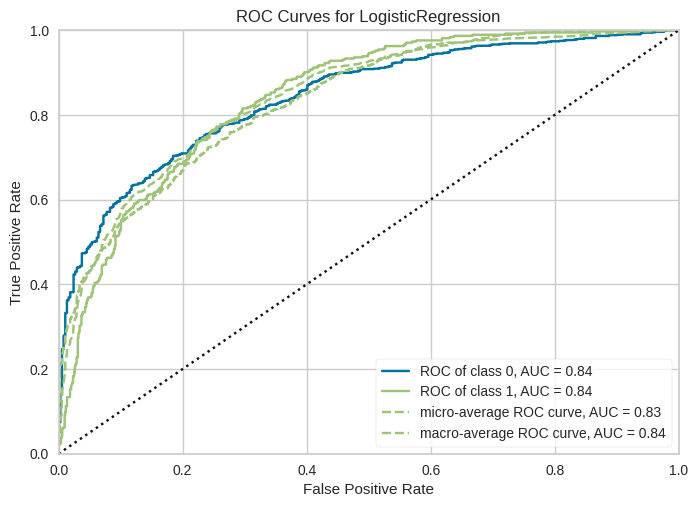

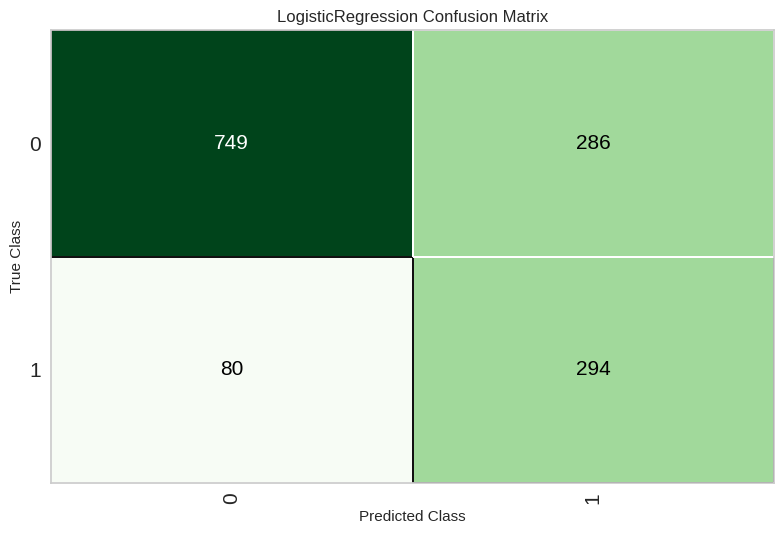

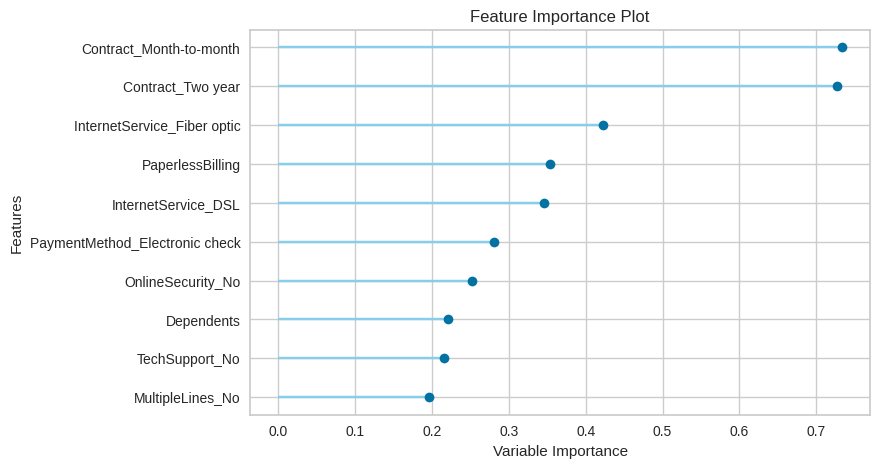

In [ ]:
from IPython.display import Image, display
for nombre in ["AUC.png", "Confusion Matrix.png", "Feature Importance.png"]:
    display(Image(nombre))

## 4. Regresión logística con scikit-learn (Daniel)
Usar `X_train`, `X_test`, `y_train`, `y_test` de la sección 2.2.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

modelo_lr = Pipeline([
    ("prep", prep),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
])

t0 = time.time()
modelo_lr.fit(X_train, y_train)
tiempo_lr = time.time() - t0

y_pred_lr = modelo_lr.predict(X_test)
y_proba_lr = modelo_lr.predict_proba(X_test)[:, 1]
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Regresión logística -> F1: {f1_lr:.4f} | ROC-AUC: {auc_lr:.4f} | Tiempo: {tiempo_lr:.2f}s")

Regresión logística -> F1: 0.6136 | ROC-AUC: 0.8416 | Tiempo: 0.10s


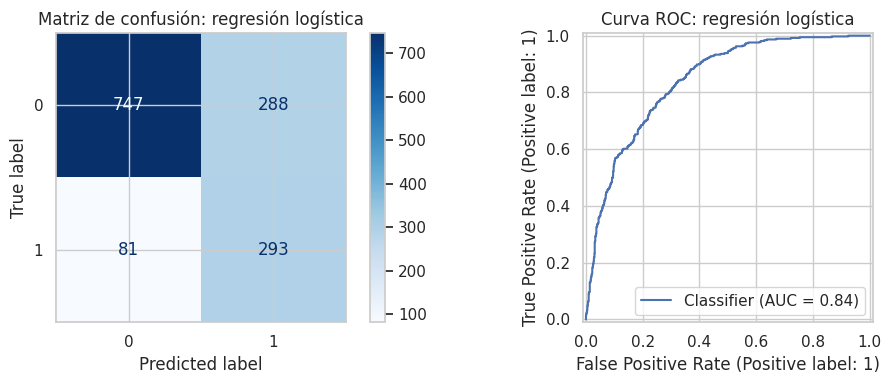

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap="Blues")
axes[0].set_title("Matriz de confusión: regresión logística")
RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=axes[1])
axes[1].set_title("Curva ROC: regresión logística")
plt.tight_layout()
plt.show()

## 5. Comparación final (Daniel y Bryam)

In [ ]:
# Ejecutar después de las secciones 3 y 4
filas = [{
    "Modelo": "Regresión logística (sklearn)",
    "F1-score": f1_lr,
    "ROC-AUC": auc_lr,
    "Tiempo de entrenamiento (s)": tiempo_lr,
    "Líneas de código aprox.": 15,  # ajustar con el valor real
}]

if "r" in globals():  # solo si ya se ejecutó la sección 3 (Bryam)
    filas.insert(0, {
        "Modelo": f"PyCaret ({r['modelo']})",
        "F1-score": f1_pycaret,
        "ROC-AUC": auc_pycaret,
        "Tiempo de entrenamiento (s)": tiempo_pycaret,
        "Líneas de código aprox.": 8,  # ajustar con el valor real
    })
else:
    print("⚠ Faltan los resultados de PyCaret (sección 3). Se muestra solo la regresión logística.")

comparacion = pd.DataFrame(filas).round(4)
display(comparacion)

,Modelo,F1-score,ROC-AUC,Tiempo de entrenamiento (s),Líneas de código aprox.
0,PyCaret (LogisticRegression),0.6164,0.8419,223.5068,8
1,Regresión logística (sklearn),0.6136,0.8416,0.0998,15


### Interpretación (Daniel y Bryam)
*Completar con los números reales.*
- ¿Qué modelo obtuvo mejor F1 y ROC-AUC, y por cuánto?
- ¿Cuánto más tardó PyCaret que la regresión logística?
- ¿Vale la pena el costo en tiempo? ¿Qué se gana en facilidad de uso?